In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:


def preprocess_data_window(filtered_time, data_orig, n_previous_events, random_state=42, dataset_fraction=0.7):
    # Ensure we only use the specified fraction of the continuous dataset from the end
    # This preserves temporal order for the subsequent .shift() operations
    limit = int(len(filtered_time) * (1 - dataset_fraction))
    filtered_time = filtered_time.iloc[limit:].copy()
    data_orig = data_orig.iloc[limit:].copy()

    base_mask = filtered_time["time_to_next_ev_hr"] != -1
    filter_mask = base_mask.copy()
    for i in range(1, n_previous_events+1):
        base_mask &= base_mask.shift(i) # checking events n-1, n-2, n-3 to see if valid
    filter_mask &= base_mask.shift(-1) # checking the event n+1 to see if it is valid
    filter_mask.fillna(False, inplace=True)

    feature_cols = ["tide_deriv", "form_fac", "time_since", "slip_size", "high_t_evt", "tide_height"]
    X = data_orig[feature_cols].copy()
    X['time_since'] *= 60
    y = filtered_time["time_to_next_ev_hr"] * 3600

    '''First make pairs of feature rows with its previous n events.'''
    windows = [X]
    for i in range(1, n_previous_events+1):
        shifted = X.shift(i)
        shifted.columns = [f"{col}-{i}" for col in feature_cols]
        windows.append(shifted)
    
    windows[0].columns = [f"{col}-0" for col in feature_cols]
    
    X_full = pd.concat(windows, axis=1).loc[filter_mask] # combine window of events with original event
    y = filtered_time.loc[filter_mask, "time_to_next_ev_hr"] * 3600

    print("X shape: ", X_full.shape)
    print("y shape: ", y.shape)

    X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=random_state)

    return X_train, X_val, X_test, y_train, y_val, y_test, feature_cols

In [18]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")


In [19]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events
)


print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())


X shape:  (2231, 126)
y shape:  (2231,)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
time_since-0      0
slip_size-0       0
high_t_evt-0      0
                 ..
form_fac-20       0
time_since-20     0
slip_size-20      0
high_t_evt-20     0
tide_height-20    0
Length: 126, dtype: int64
Total NaN: 0


In [20]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2,
    "shots": 4096,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "XGBoost"
n_previous_events = 20

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)


QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost


In [21]:
# ── Cell 5: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")


Input to quantum circuit: (1338, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21


In [22]:
# ── Cell 6: Unsupervised regime labelling (K-Means on y_train) + classifier ───

import numpy as np
import optuna
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, classification_report,
                             silhouette_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Step 1: K-Means fit on y_train_np only ───────────────────────────────────
km_y = KMeans(n_clusters=2, n_init=50, random_state=42)
km_y.fit(y_train_np.reshape(-1, 1))

order   = np.argsort(km_y.cluster_centers_.ravel())
remap   = {old: new for new, old in enumerate(order)}
centers = km_y.cluster_centers_.ravel()[order]

def _km_label(y_arr):
    """Assign regime labels via trained K-Means.
    ONLY call with y_train_np — calling with val/test y leaks future targets."""
    raw = km_y.predict(y_arr.reshape(-1, 1))
    return np.array([remap[r] for r in raw])

# Train labels only — the only split where y is available at fit time
y_clf_train = _km_label(y_train_np)

boundary = centers.mean()
print(f"K-Means cluster centres — Short: {centers[0]:.0f} s, Long: {centers[1]:.0f} s")
print(f"Decision boundary (midpoint): {boundary:.0f} s")

sil_train = silhouette_score(y_train_np.reshape(-1, 1), y_clf_train)
print(f"Silhouette score — Train: {sil_train:.4f}")
print(f"Class distribution (train) — Short: {(y_clf_train==0).sum()}, Long: {(y_clf_train==1).sum()}")

# ── Step 2: Train XGBoost classifier on raw X_train features → y_clf_train ───
# Raw features preserve separability that [0, π] scaling compresses.
# The QRC and regressors downstream still use X_train_q — only the classifier
# uses the unscaled features.
X_train_raw = X_train.to_numpy()
X_val_raw   = X_val.to_numpy()
X_test_raw  = X_test.to_numpy()

sample_weights_clf = compute_sample_weight("balanced", y_clf_train)

def clf_objective(trial):
    clf = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        random_state=42,
    )
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_accs = []
    for train_idx, val_idx in skf.split(X_train_raw, y_clf_train):
        X_f, X_v = X_train_raw[train_idx], X_train_raw[val_idx]
        y_f, y_v = y_clf_train[train_idx], y_clf_train[val_idx]
        w_f      = sample_weights_clf[train_idx]
        clf.fit(X_f, y_f, sample_weight=w_f, verbose=False)
        fold_accs.append(accuracy_score(y_v, clf.predict(X_v)))
    return 1.0 - np.mean(fold_accs)

clf_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
clf_study.optimize(clf_objective, n_trials=30)

slip_classifier = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    **clf_study.best_params,
    random_state=42,
    eval_metric="logloss",
)
slip_classifier.fit(
    X_train_raw, y_clf_train,
    sample_weight=sample_weights_clf,
    verbose=False,
)

# ── Step 3: All routing masks from classifier predictions on X (no y used) ────
clf_train_labels = slip_classifier.predict(X_train_raw)
clf_val_labels   = slip_classifier.predict(X_val_raw)
clf_test_labels  = slip_classifier.predict(X_test_raw)

short_mask_train = clf_train_labels == 0
long_mask_train  = clf_train_labels == 1
short_mask_val   = clf_val_labels   == 0
long_mask_val    = clf_val_labels   == 1

short_test_idx = np.where(clf_test_labels == 0)[0]
long_test_idx  = np.where(clf_test_labels == 1)[0]
short_val_idx  = np.where(clf_val_labels  == 0)[0]
long_val_idx   = np.where(clf_val_labels  == 1)[0]

print(f"\nPredicted class distribution — Train: Short {short_mask_train.sum()}, Long {long_mask_train.sum()}")
print(f"Test routing  — Short: {len(short_test_idx)}, Long: {len(long_test_idx)}")
print(f"Val routing   — Short: {len(short_val_idx)},  Long: {len(long_val_idx)}")



c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


K-Means cluster centres — Short: 46007 s, Long: 83706 s
Decision boundary (midpoint): 64856 s
Silhouette score — Train: 0.7187
Class distribution (train) — Short: 815, Long: 523

Predicted class distribution — Train: Short 815, Long 523
Test routing  — Short: 244, Long: 203
Val routing   — Short: 252,  Long: 194


In [23]:
# ── Cell 7: FC-TFI Hamiltonian ────────────────────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()

    for layer in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()

        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)


In [24]:
# ── Cell 8: Pauli runner — quantum features only, no classical concatenation ───
def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    expectations = np.zeros(3 * n_qubits)

    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        qc_meas = circuit_base.copy()

        if basis == 'X':
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == 'Y':
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (
                    (1 - 2 * bit) * count / shots
                )

    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    counts_zz = result_zz.get_counts()

    for bitstring, count in counts_zz.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            j = (i + 1) % n_qubits
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (
                (1 - 2*bit_i) * (1 - 2*bit_j) * count / shots
            )

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli(
    X_data, angle_bank, num_layers, n_qubits, n_total_events, shots
):
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m         = X_data.shape[0]
    n_obs     = 3 * n_qubits + n_qubits  # 24
    simulator = AerSimulator()
    #simulator = AerSimulator(device='GPU')
    #simulator.set_options(cuStateVec_enable=True)
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col    = event_idx * n_qubits
        end_col      = start_col + n_qubits
        X_event      = X_data[:, start_col:end_col]
        ising_params = angle_bank[event_idx]

        for sample_idx in range(m):
            qc = build_reservoir_circuit_rotations(
                X_event[sample_idx], ising_params, num_layers, n_qubits
            )
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features_decay(P_matrix, X_classical, n_total_events, n_obs, decay=0.3):
    weights = np.array([
        np.exp(-decay * (n_total_events - 1 - i))
        for i in range(n_total_events)
    ])
    weights /= weights.sum()

    weighted_P = P_matrix.copy()
    for event_idx in range(n_total_events):
        start = event_idx * n_obs
        end   = start + n_obs
        weighted_P[:, start:end] *= weights[event_idx]
    return weighted_P


In [25]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":   "reg:squarederror",
                "n_estimators": 2000,
                "random_state": 42,
                "tree_method":  "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            # optuna_fit_fn: plain fit — used only inside Optuna CV objectives.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt, verbose=False),
            # fit_fn: plain fit, no eval_set, no early stopping.
            # n_estimators is fixed; val is kept clean for iteration ranking.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, verbose=False),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            # optuna_fit_fn: plain fit, no eval_set — avoids val leakage.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            # fit_fn: plain fit, no eval_set, no use_best_model.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")


Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: XGBoost


In [26]:
# ── Cell 10: Single iteration — pre-classified regime-specific reservoirs ──────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    shots          = config["shots"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 24

    rng_short = np.random.default_rng(seed)
    rng_long  = np.random.default_rng(seed + 10000)

    angle_bank_short = [
        generate_random_angles(num_layers, n_qubits, rng_short)
        for _ in range(n_total_events)
    ]
    angle_bank_long = [
        generate_random_angles(num_layers, n_qubits, rng_long)
        for _ in range(n_total_events)
    ]

    # ── Step 1: Split train/val by classifier-predicted regime ────────────────
    # short_mask_train/val are derived from classifier predictions on X (Cell 6)
    X_tr_short = X_train_q[short_mask_train]
    X_tr_long  = X_train_q[long_mask_train]
    X_vl_short = X_val_q[short_mask_val]
    X_vl_long  = X_val_q[long_mask_val]

    y_tr_short = y_train_np[short_mask_train]
    y_tr_long  = y_train_np[long_mask_train]
    y_vl_short = y_val_np[short_mask_val]
    y_vl_long  = y_val_np[long_mask_val]

    print(f"  Short regime — train: {len(y_tr_short)}, val: {len(y_vl_short)}")
    print(f"  Long  regime — train: {len(y_tr_long)},  val: {len(y_vl_long)}")

    # ── Step 2: Run SHORT regime reservoir ────────────────────────────────────
    print(f"  Running SHORT FC-TFI reservoir on train ({len(X_tr_short)} samples)...")
    P_tr_short = run_quantum_reservoir_pauli(
        X_tr_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on val ({len(X_vl_short)} samples)...")
    P_vl_short = run_quantum_reservoir_pauli(
        X_vl_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on test ({len(short_test_idx)} samples)...")
    P_te_short = run_quantum_reservoir_pauli(
        X_test_q[short_test_idx], angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 3: Run LONG regime reservoir ─────────────────────────────────────
    print(f"  Running LONG FC-TFI reservoir on train ({len(X_tr_long)} samples)...")
    P_tr_long = run_quantum_reservoir_pauli(
        X_tr_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on val ({len(y_vl_long)} samples)...")
    P_vl_long = run_quantum_reservoir_pauli(
        X_vl_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on test ({len(long_test_idx)} samples)...")
    P_te_long = run_quantum_reservoir_pauli(
        X_test_q[long_test_idx], angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 4: Quantum-only features with decay ──────────────────────────────
    H_tr_short = make_hybrid_features_decay(P_tr_short, X_tr_short, n_total_events, n_obs)
    H_vl_short = make_hybrid_features_decay(P_vl_short, X_vl_short, n_total_events, n_obs)
    H_te_short = make_hybrid_features_decay(P_te_short, X_test_q[short_test_idx], n_total_events, n_obs)

    H_tr_long  = make_hybrid_features_decay(P_tr_long,  X_tr_long,  n_total_events, n_obs)
    H_vl_long  = make_hybrid_features_decay(P_vl_long,  X_vl_long,  n_total_events, n_obs)
    H_te_long  = make_hybrid_features_decay(P_te_long,  X_test_q[long_test_idx], n_total_events, n_obs)

    entry = registry[model_name]

    # ── Step 5: Tune and train SHORT sub-regressor ────────────────────────────
    # Optuna objectives use KFold CV within train only.
    # The val set is never seen during hyperparameter search or final refit —
    # it remains a fully clean, unbiased signal for iteration ranking.
    from sklearn.model_selection import KFold

    _n_cv_folds = 3   # 3-fold is a reasonable default for small regime subsets

    def _cv_mae(entry, params, H_tr, y_tr, rng_seed):
        """Return mean CV-MAE over KFold splits of the training data."""
        kf     = KFold(n_splits=_n_cv_folds, shuffle=True, random_state=rng_seed)
        maes   = []
        optuna_fit = entry.get("optuna_fit_fn", lambda m, Xt, yt: m.fit(Xt, yt))
        for fold_tr, fold_vl in kf.split(H_tr):
            m = entry["build_fn"](params)
            optuna_fit(m, H_tr[fold_tr], y_tr[fold_tr])
            maes.append(mean_absolute_error(y_tr[fold_vl], m.predict(H_tr[fold_vl])))
        return float(np.mean(maes))

    def short_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr_short, y_tr_short, seed)

    short_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    short_study.optimize(short_objective, n_trials=30)

    # Final refit on full train split; val used only for early stopping
    short_tuned  = entry["optuna_fn"](short_study.best_trial)
    short_params = {**entry["fixed_params"], **short_tuned}
    model_short  = entry["build_fn"](short_params)
    entry["fit_fn"](model_short, H_tr_short, y_tr_short, H_vl_short, y_vl_short)

    # ── Step 6: Tune and train LONG sub-regressor ─────────────────────────────
    def long_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr_long, y_tr_long, seed + 1)

    long_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed + 1),
    )
    long_study.optimize(long_objective, n_trials=30)

    long_tuned  = entry["optuna_fn"](long_study.best_trial)
    long_params = {**entry["fixed_params"], **long_tuned}
    model_long  = entry["build_fn"](long_params)
    entry["fit_fn"](model_long, H_tr_long, y_tr_long, H_vl_long, y_vl_long)

    short_val_mae = mean_absolute_error(y_vl_short, model_short.predict(H_vl_short))
    long_val_mae  = mean_absolute_error(y_vl_long,  model_long.predict(H_vl_long))
    print(f"  Short regime val MAE: {short_val_mae:.2f}s")
    print(f"  Long  regime val MAE: {long_val_mae:.2f}s")

    # ── Step 7: Test predictions routed by classifier ─────────────────────────
    test_pred = np.empty(len(X_test_q))
    if len(short_test_idx) > 0:
        test_pred[short_test_idx] = model_short.predict(H_te_short)
    if len(long_test_idx) > 0:
        test_pred[long_test_idx]  = model_long.predict(H_te_long)

    # ── Step 8: Val predictions using already-computed reservoir outputs ───────
    val_pred = np.empty(len(X_val_q))

    short_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(short_mask_val)[0])
    }
    long_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(long_mask_val)[0])
    }

    for idx in short_val_idx:
        assert idx in short_val_positions, (
            f"Val index {idx} was predicted short by classifier but missing from "
            f"short_mask_val — masks are inconsistent."
        )
        pos = short_val_positions[idx]
        val_pred[idx] = model_short.predict(H_vl_short[pos:pos+1])[0]

    for idx in long_val_idx:
        assert idx in long_val_positions, (
            f"Val index {idx} was predicted long by classifier but missing from "
            f"long_mask_val — masks are inconsistent."
        )
        pos = long_val_positions[idx]
        val_pred[idx] = model_long.predict(H_vl_long[pos:pos+1])[0]

    # ── Step 9: Metrics ───────────────────────────────────────────────────────
    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     mean_absolute_error(y_val_np, val_pred),
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": {"short": short_params, "long": long_params},
        # FIX #4: store both regime models and all three reservoir matrices for
        # both regimes so per-iteration analysis of long-regime outputs is possible.
        "model_short":   model_short,
        "model_long":    model_long,
        "model":         model_short,            # backward-compat alias
        "P_train_short": P_tr_short,
        "P_val_short":   P_vl_short,
        "P_test_short":  P_te_short,
        "P_train_long":  P_tr_long,
        "P_val_long":    P_vl_long,
        "P_test_long":   P_te_long,
        # Legacy keys — kept so existing downstream cells don't break
        "P_train": P_tr_short, "P_val": P_vl_short, "P_test": P_te_short,
    }


In [12]:
# ── Cell 11: Pipeline + run ───────────────────────────────────────────────────
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    # ── Honest headline: mean over ALL iterations (no val-based selection) ──────
    # Headline is the mean of every iteration's test predictions.
    all_test_preds = np.array([r["test_pred"] for r in results])
    ensemble_pred  = all_test_preds.mean(axis=0)   # shape: (n_test,)
    ensemble_rmse  = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae   = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2    = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble (all {len(results)} iterations — unbiased headline):")
    print(f"  Test RMSE: {ensemble_rmse:.2f}")
    print(f"  Test MAE:  {ensemble_mae:.2f}")
    print(f"  Test R2:   {ensemble_r2:.4f}")

    # ── Secondary: top-k by val MAE (optimistic upper bound, report separately) ─
    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    top_k_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    top_k_rmse = root_mean_squared_error(y_test_np, top_k_pred)
    top_k_mae  = mean_absolute_error(y_test_np, top_k_pred)
    top_k_r2   = r2_score(y_test_np, top_k_pred)

    print(f"\nTop-{top_k} ensemble by val MAE (optimistic — val used for selection):")
    print(f"  Iterations: {[i + 1 for i in top_indices]}")
    print(f"  Test RMSE: {top_k_rmse:.2f}")
    print(f"  Test MAE:  {top_k_mae:.2f}")
    print(f"  Test R2:   {top_k_r2:.4f}")

    # ── Per-regime test breakdown — classifier-predicted routing only ──────────
    short_clf_test = np.where(clf_test_labels == 0)[0]
    long_clf_test  = np.where(clf_test_labels == 1)[0]

    print(f"\n=== Ensemble Per-Regime Test MAE (classifier-predicted routing) ===")
    if len(short_clf_test) > 0:
        ensemble_short_mae = mean_absolute_error(
            y_test_np[short_clf_test], ensemble_pred[short_clf_test]
        )
        print(f"Short regime (classifier predicted, n={len(short_clf_test)}): "
              f"MAE = {ensemble_short_mae:.2f}s")
    if len(long_clf_test) > 0:
        ensemble_long_mae = mean_absolute_error(
            y_test_np[long_clf_test], ensemble_pred[long_clf_test]
        )
        print(f"Long  regime (classifier predicted, n={len(long_clf_test)}):  "
              f"MAE = {ensemble_long_mae:.2f}s")


    return results, ensemble_pred, top_indices


all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, QRC_CONFIG,
    "XGBoost",
    registry,
)



Iteration 1/5:
  Short regime — train: 944, val: 348
  Long  regime — train: 478,  val: 127
  Running SHORT FC-TFI reservoir on train (944 samples)...


KeyboardInterrupt: 

In [27]:
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, accuracy_score

# 1. Convert to numpy; split by CLASSIFIER-predicted regime (no y used)

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

X_train_np = X_train_raw
X_val_np   = X_val_raw
X_test_np  = X_test_raw

# short_mask_train/val already set in Cell 6 from classifier predictions 
X_tr_short, y_tr_short = X_train_np[short_mask_train], y_train_np[short_mask_train]
X_vl_short, y_vl_short = X_val_np[short_mask_val],     y_val_np[short_mask_val]
X_tr_long,  y_tr_long  = X_train_np[long_mask_train],  y_train_np[long_mask_train]
X_vl_long,  y_vl_long  = X_val_np[long_mask_val],      y_val_np[long_mask_val]

print(f"Sub-regressor training samples — Short: {len(y_tr_short)}, Long: {len(y_tr_long)}")

# 2. Optuna tuning — SHORT sub-regressor
# CV-within-train only; no eval_set / val signal in
# the objective.  The val split is untouched during search and is used
# only in the final refit (early stopping is fine there).

from sklearn.model_selection import KFold

_N_CV  = 3   # 3-fold CV; increase if short-regime train set is large enough

def _xgb_cv_rmse(X_tr, y_tr, params, n_folds=_N_CV, seed=42):
    """KFold CV-RMSE using plain fit (no eval_set) — leak-free objective."""
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, vl_idx in kf.split(X_tr):
        m = XGBRegressor(**params, random_state=seed)
        m.fit(X_tr[tr_idx], y_tr[tr_idx], verbose=False)   # NO eval_set
        rmses.append(root_mean_squared_error(y_tr[vl_idx], m.predict(X_tr[vl_idx])))
    return float(np.mean(rmses))

_short_search_params = dict(
    objective="reg:squarederror",
    n_estimators=1000,
)

def objective_short(trial):
    params = {
        **_short_search_params,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 5),
        "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
    }
    return _xgb_cv_rmse(X_tr_short, y_tr_short, params, seed=42)

opt_short = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
opt_short.optimize(objective_short, n_trials=30)
print("Short sub-regressor optimal params:", opt_short.best_params)

# 3. Optuna tuning — LONG sub-regressor

def objective_long(trial):
    params = {
        **_short_search_params,   # same base; reuse dict
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 5),
        "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
    }
    return _xgb_cv_rmse(X_tr_long, y_tr_long, params, seed=42)

opt_long = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42))
opt_long.optimize(objective_long, n_trials=30)
print("Long sub-regressor optimal params:", opt_long.best_params)

# 4. Train final sub-regressors — no eval_set, no early stopping, val stays clean

XGBoost_short = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **opt_short.best_params,
    random_state=42,
)
XGBoost_short.fit(X_tr_short, y_tr_short, verbose=False)

XGBoost_long = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **opt_long.best_params,
    random_state=42,
)
XGBoost_long.fit(X_tr_long, y_tr_long, verbose=False)


# 5. Inference — classifier routes on X only


final_predictions = np.empty(len(X_test_np))
short_idx = np.where(clf_test_labels == 0)[0]
long_idx  = np.where(clf_test_labels == 1)[0]

if len(short_idx) > 0:
    final_predictions[short_idx] = XGBoost_short.predict(X_test_np[short_idx])
if len(long_idx) > 0:
    final_predictions[long_idx] = XGBoost_long.predict(X_test_np[long_idx])


# 6. Evaluate — all splits use clf_test_labels (X only)


overall_RMSE = root_mean_squared_error(y_test_np, final_predictions)
overall_MAE  = mean_absolute_error(y_test_np, final_predictions)

print("\n=== Constrained XGBoost — Overall Test Performance ===")
print(f"RMSE: {overall_RMSE:.2f} s")
print(f"MAE:  {overall_MAE:.2f} s")

# Per-class breakdown by classifier-predicted regime (inference-consistent).

if len(short_idx) > 0:
    rmse_s = root_mean_squared_error(y_test_np[short_idx], final_predictions[short_idx])
    mae_s  = mean_absolute_error(y_test_np[short_idx],     final_predictions[short_idx])
    print(f"\nShort regime (classifier predicted, n={len(short_idx)}) — RMSE: {rmse_s:.2f}s  MAE: {mae_s:.2f}s")

if len(long_idx) > 0:
    rmse_l = root_mean_squared_error(y_test_np[long_idx], final_predictions[long_idx])
    mae_l  = mean_absolute_error(y_test_np[long_idx],     final_predictions[long_idx])
    print(f"Long  regime (classifier predicted, n={len(long_idx)}) — RMSE: {rmse_l:.2f}s  MAE: {mae_l:.2f}s")



Sub-regressor training samples — Short: 815, Long: 523
Short sub-regressor optimal params: {'learning_rate': 0.022732535826396397, 'max_depth': 5, 'subsample': 0.6021161571640921, 'colsample_bytree': 0.7332503199401906}
Long sub-regressor optimal params: {'learning_rate': 0.012573160527906113, 'max_depth': 5, 'subsample': 0.804701870441273, 'colsample_bytree': 0.6347174985988778}

=== Constrained XGBoost — Overall Test Performance ===
RMSE: 18121.53 s
MAE:  9967.43 s

Short regime (classifier predicted, n=244) — RMSE: 14623.06s  MAE: 7739.26s
Long  regime (classifier predicted, n=203) — RMSE: 21588.95s  MAE: 12645.63s


In [28]:
# ── High-confidence performance ────────

clf_test_proba = slip_classifier.predict_proba(X_test_raw)   # shape (n, 2)
max_conf       = clf_test_proba.max(axis=1)                   # confidence in chosen class

threshold_high = 0.80   # high-confidence subset (likely correct routing)
threshold_low  = 0.60   # low-confidence subset  (likely uncertain routing)

high_conf_idx = np.where(max_conf >= threshold_high)[0]
low_conf_idx  = np.where(max_conf <  threshold_low)[0]
mid_conf_idx  = np.where((max_conf >= threshold_low) & (max_conf < threshold_high))[0]

print(f"High-confidence samples (≥{threshold_high:.0%}): {len(high_conf_idx)} / {len(y_test_np)} "
      f"({100*len(high_conf_idx)/len(y_test_np):.1f}%)")
print(f"Mid-confidence  samples:                         {len(mid_conf_idx)} / {len(y_test_np)} "
      f"({100*len(mid_conf_idx)/len(y_test_np):.1f}%)")
print(f"Low-confidence  samples (<{threshold_low:.0%}):  {len(low_conf_idx)} / {len(y_test_np)} "
      f"({100*len(low_conf_idx)/len(y_test_np):.1f}%)")

# ── Full-pipeline metrics first — this is the honest headline ─────────────────
print(f"Full pipeline performance (headline metric — all samples):")
print(f"  MAE:  {mean_absolute_error(y_test_np, final_predictions):.2f}s")
print(f"  RMSE: {root_mean_squared_error(y_test_np, final_predictions):.2f}s")
print(f"  R²:   {r2_score(y_test_np, final_predictions):.4f}")

# ── High-confidence subset ───────────
# This is a self-selected best-performing subset
if len(high_conf_idx) > 0:
    mae_hc   = mean_absolute_error(y_test_np[high_conf_idx],  final_predictions[high_conf_idx])
    rmse_hc  = root_mean_squared_error(y_test_np[high_conf_idx], final_predictions[high_conf_idx])
    r2_hc    = r2_score(y_test_np[high_conf_idx],             final_predictions[high_conf_idx])
    pct_hc   = 100 * len(high_conf_idx) / len(y_test_np)
    print(f"\n[Supporting] High-confidence subset (≥80%, {pct_hc:.1f}% of test samples):")
    print(f"  NOTE: self-selected subset — lower MAE expected, not a fair headline.")
    print(f"  MAE:  {mae_hc:.2f}s")
    print(f"  RMSE: {rmse_hc:.2f}s")
    print(f"  R²:   {r2_hc:.4f}")


High-confidence samples (≥80%): 305 / 447 (68.2%)
Mid-confidence  samples:                         102 / 447 (22.8%)
Low-confidence  samples (<60%):  40 / 447 (8.9%)
Full pipeline performance (headline metric — all samples):
  MAE:  9967.43s
  RMSE: 18121.53s
  R²:   0.2473

[Supporting] High-confidence subset (≥80%, 68.2% of test samples):
  NOTE: self-selected subset — lower MAE expected, not a fair headline.
  MAE:  7175.80s
  RMSE: 14371.34s
  R²:   0.5141


In [15]:
# ── Confidence-tier cost analysis ─────────────
#
# Show how MAE degrades as classifier confidence drops.
# All splits based on clf_test_proba (X-only). No y_test used for routing.

print(f"High-conf  (≥{threshold_high:.0%}, n={len(high_conf_idx):4d}): "
      f"MAE = {mean_absolute_error(y_test_np[high_conf_idx],  final_predictions[high_conf_idx]):.2f}s"
      if len(high_conf_idx) > 0 else f"High-conf: no samples")

print(f"Mid-conf          (n={len(mid_conf_idx):4d}): "
      f"MAE = {mean_absolute_error(y_test_np[mid_conf_idx],   final_predictions[mid_conf_idx]):.2f}s"
      if len(mid_conf_idx) > 0 else f"Mid-conf: no samples")

print(f"Low-conf   (<{threshold_low:.0%}, n={len(low_conf_idx):4d}): "
      f"MAE = {mean_absolute_error(y_test_np[low_conf_idx],   final_predictions[low_conf_idx]):.2f}s"
      if len(low_conf_idx) > 0 else f"Low-conf: no samples")

print(f"All samples        (n={len(y_test_np):4d}): "
      f"MAE = {mean_absolute_error(y_test_np, final_predictions):.2f}s")


High-conf  (≥80%, n= 316): MAE = 6000.40s
Mid-conf          (n= 110): MAE = 15943.36s
Low-conf   (<60%, n=  49): MAE = 21314.38s
All samples        (n= 475): MAE = 9882.74s


In [16]:
# Classical R^2 value 
print(f"R2: {r2_score(y_test_np, final_predictions):.4f}")


R2: 0.1609


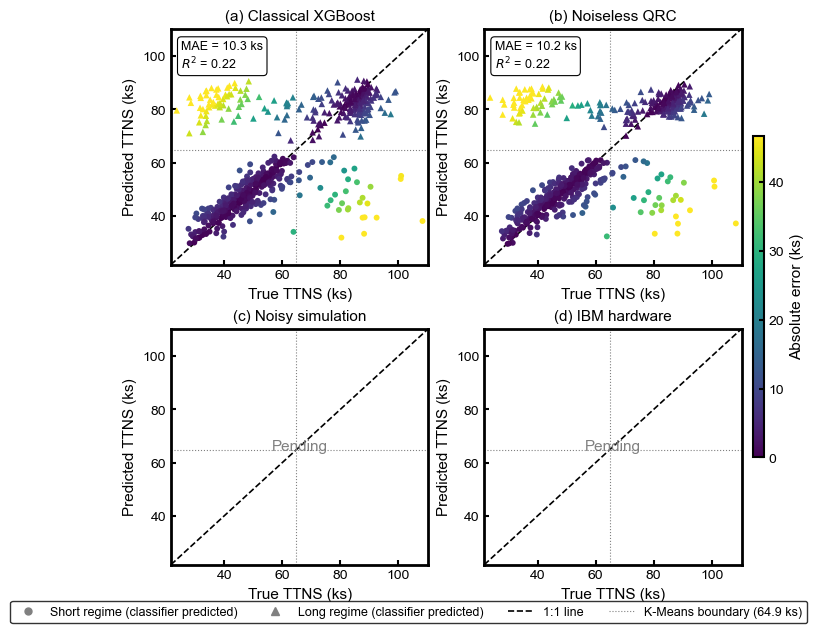

In [ ]:
# ── Four-panel publication figure: Classical / Noiseless QRC / Noisy sim / Hardware
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.style':        'normal',
    'font.weight':       'normal',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
})

# ── Data preparation ──────────────────────────────────────────────────────────
y_true = np.array(y_test_np)

# Classical XGBoost — from constrained pipeline
classical_preds  = np.array(final_predictions)
classical_errors = np.abs(classical_preds - y_true)

# Noiseless QRC — only available if the QRC pipeline has been run
try:
    qrc_preds  = np.array(ensemble_pred)
    qrc_errors = np.abs(qrc_preds - y_true)
    _qrc_available = True
except NameError:
    qrc_preds  = None
    qrc_errors = None
    _qrc_available = False
    print("Note: ensemble_pred not found — QRC panel will show 'Pending'.")

# Noisy simulation and hardware — leave as None until available
noisy_preds    = None
hardware_preds = None

# ── Regime index masks — classifier predictions on X (inference-consistent) ───
short_idx = clf_test_labels == 0
long_idx  = clf_test_labels == 1

km_boundary = centers.mean()

# ── Axis limits ───────────────────────────────────────────────────────────────
_all_defined = [y_true, classical_preds] + ([qrc_preds] if _qrc_available else [])
all_vals = np.concatenate(_all_defined)
ax_min   = max(0, np.min(all_vals) - 2000)
ax_max   = np.max(all_vals) + 2000
diag     = [ax_min, ax_max]

# ── Colormap and normalisation ────────────────────────────────────────────────
_err_arrays = [classical_errors] + ([qrc_errors] if _qrc_available else [])
all_errors = np.concatenate(_err_arrays)
vmin, vmax = 0, np.percentile(all_errors, 95)
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)


# ── Plotting function ─────────────────────────────────────────────────────────
def scatter_regime(ax, y_true, y_pred, errors, title,
                   short_idx, long_idx, is_placeholder=False):
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)

    ax.plot(diag, diag, color='black', linewidth=1.2,
            linestyle='--', zorder=1, label='1:1 line')

    ax.axvline(km_boundary, color='grey', linestyle=':',
               linewidth=0.8, zorder=1)
    ax.axhline(km_boundary, color='grey', linestyle=':',
               linewidth=0.8, zorder=1)

    if is_placeholder:
        ax.text(
            0.5, 0.5, 'Pending',
            transform=ax.transAxes,
            ha='center', va='center',
            fontsize=11, color='gray'
        )
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _format_axes_ks(ax)
        return None

    ax.scatter(
        y_true[short_idx], y_pred[short_idx],
        c=errors[short_idx], cmap=cmap, norm=norm,
        s=18, marker='o', edgecolors='none', zorder=2
    )
    ax.scatter(
        y_true[long_idx], y_pred[long_idx],
        c=errors[long_idx], cmap=cmap, norm=norm,
        s=22, marker='^', edgecolors='none', zorder=2
    )

    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    ax.text(
        0.04, 0.95,
        f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
        transform=ax.transAxes,
        ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='black', linewidth=0.8)
    )

    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _format_axes_ks(ax)
    return ax


def _format_axes_ks(ax):
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
    )
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
    )


# ── Build figure ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2,
    figsize=(6.89, 6.0),
    constrained_layout=True
)

scatter_regime(axes[0, 0], y_true, classical_preds, classical_errors,
               '(a) Classical XGBoost', short_idx, long_idx)
scatter_regime(axes[0, 1], y_true, qrc_preds, qrc_errors,
               '(b) Noiseless QRC', short_idx, long_idx,
               is_placeholder=not _qrc_available)
scatter_regime(axes[1, 0], y_true, None, None,
               '(c) Noisy simulation', short_idx, long_idx, is_placeholder=True)
scatter_regime(axes[1, 1], y_true, None, None,
               '(d) IBM hardware', short_idx, long_idx, is_placeholder=True)

# ── Shared colorbar ───────────────────────────────────────────────────────────
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=30)
cbar.set_label('Absolute error (ks)', fontsize=11)
cbar.ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}')
)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_linewidth(1.5)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker='o', color='gray', linestyle='None',
           markersize=5, label=f'Short regime (classifier predicted)'),
    Line2D([0], [0], marker='^', color='gray', linestyle='None',
           markersize=6, label=f'Long regime (classifier predicted)'),
    Line2D([0], [0], color='black', linestyle='--',
           linewidth=1.2, label='1:1 line'),
    Line2D([0], [0], color='grey', linestyle=':',
           linewidth=0.8, label=f'K-Means boundary ({km_boundary/1000:.1f} ks)'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=4,
    fontsize=9,
    frameon=True,
    edgecolor='black',
    bbox_to_anchor=(0.42, -0.04)
)

'''output_path = 'insert path'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to {output_path}")'''
plt.show()


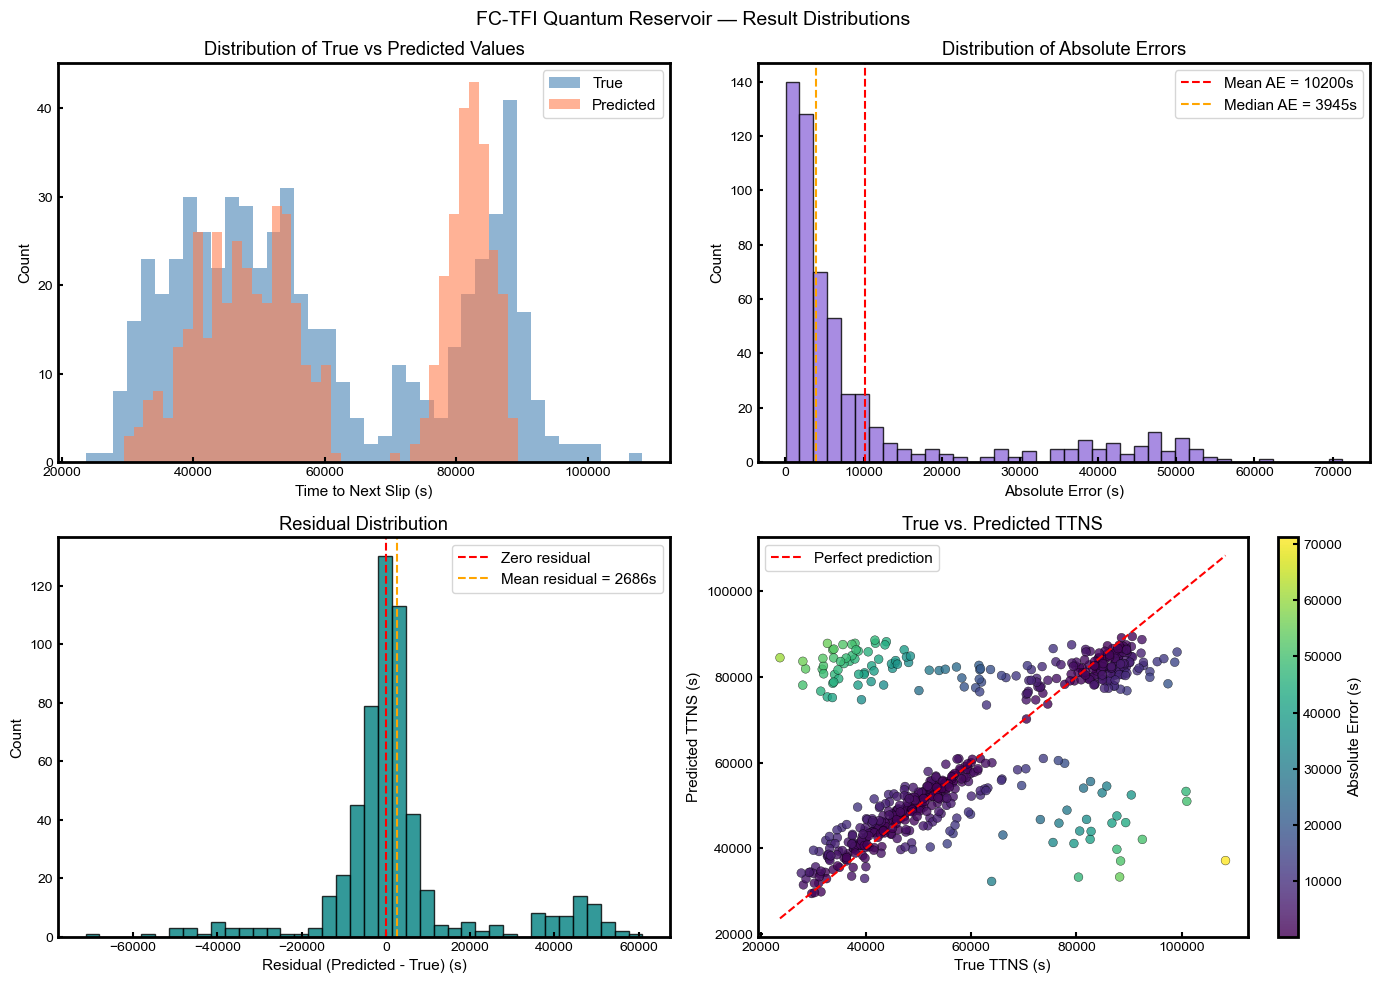

MAE:            10199.80s
Median AE:      3944.57s
RMSE:           17828.82s
R2:             0.2164
Max error:      71263.55s
% within 5000s: 57.5%
% within 9000s: 73.8%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Data distribution plot for FC-TFI run ────────────────────────────────────
y_test_secs    = y_test
QRC_pred_secs  = ensemble_pred

absolute_errors = np.abs(QRC_pred_secs - y_test_secs)
residuals       = QRC_pred_secs - y_test_secs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FC-TFI Quantum Reservoir — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted values ────────────────────────
axes[0, 0].hist(y_test_secs, bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(QRC_pred_secs, bins=40, alpha=0.6, color='coral', label='Predicted')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ──────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(), color='red', linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted - True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 4: True vs Predicted scatter ───────────────────────────────────────
sc = axes[1, 1].scatter(y_test_secs, QRC_pred_secs,
                         c=absolute_errors, cmap='viridis',
                         s=40, edgecolors='black', linewidths=0.3, alpha=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"MAE:            {mean_absolute_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"Median AE:      {np.median(absolute_errors):.2f}s")
print(f"RMSE:           {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R2:             {r2_score(y_test_secs, QRC_pred_secs):.4f}")
print(f"Max error:      {absolute_errors.max():.2f}s")
print(f"% within 5000s: {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9000s: {(absolute_errors < 9000).mean()*100:.1f}%")


  Classical XGBoost
  ──────────────────────────────────────────────────────
  High-confidence subset (≥80%, n=281)
    MAE  : 5340 s
    R²   : 0.6925
  Full pipeline (n=565)
    MAE  : 10255 s
    R²   : 0.2214

  Noiseless QRC
  ──────────────────────────────────────────────────────
  High-confidence subset (≥80%, n=281)
    MAE  : 5302 s
    R²   : 0.6882
  Full pipeline (n=565)
    MAE  : 10200 s
    R²   : 0.2164



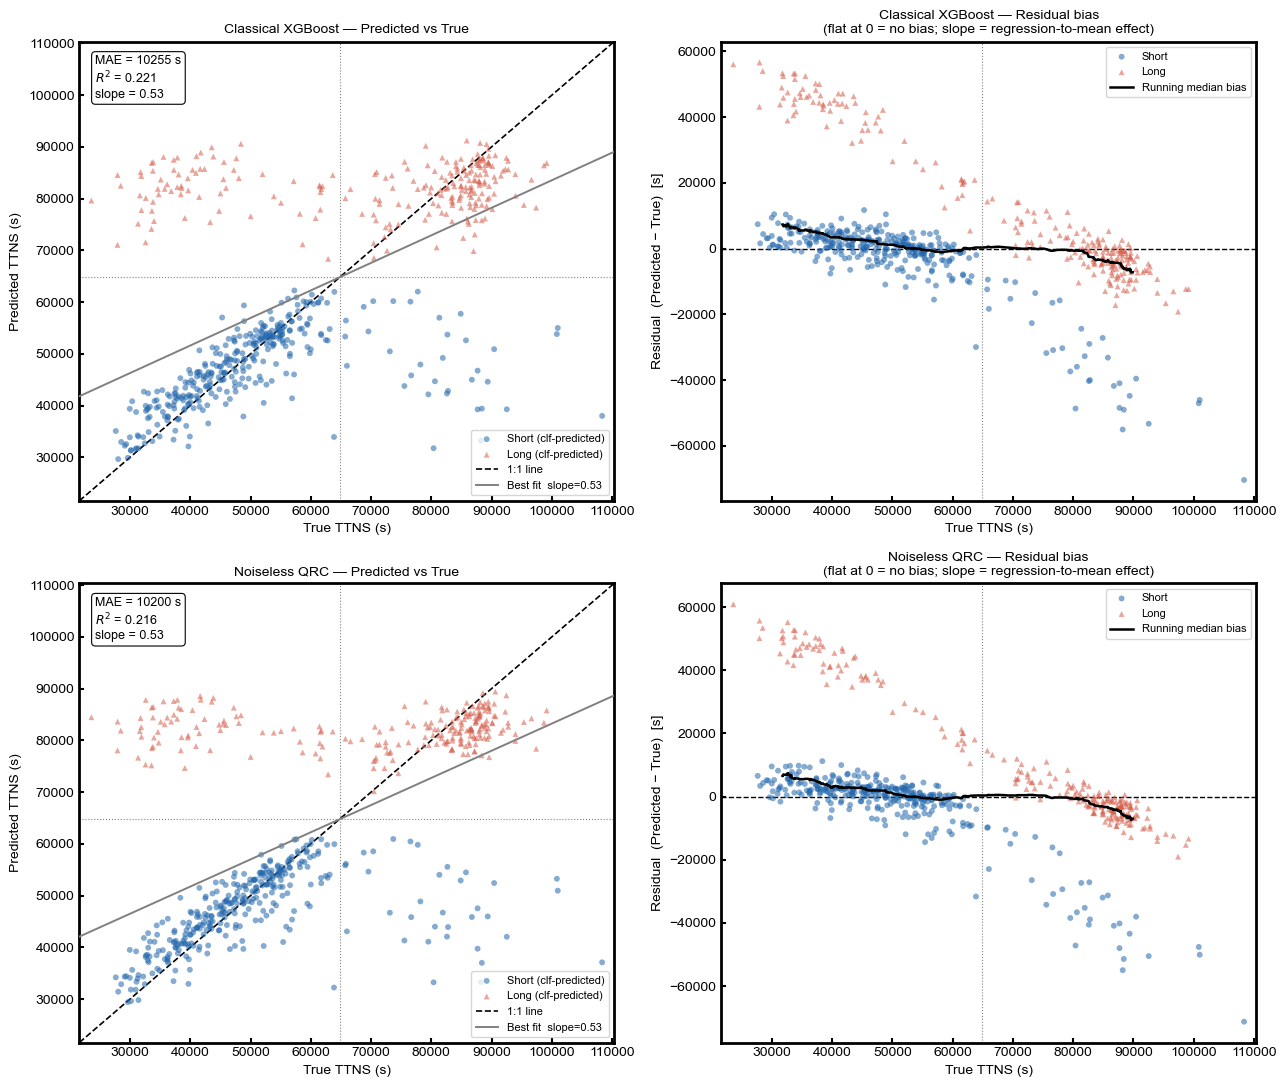

In [ ]:
# ── Prediction diagnostic — scatter + residual bias plot ─────────────────

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import linregress

try:
    _qrc_preds_sc = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

# ── Print results ─────────────────────────────────────────────────────────────
def _print_results(label, preds, y_np, hc_idx):
    from sklearn.metrics import mean_absolute_error, r2_score
    print(f"  {label}")
    print(f"  {'─'*54}")
    print(f"  High-confidence subset (≥80%, n={len(hc_idx)})")
    print(f"    MAE  : {mean_absolute_error(y_np[hc_idx], preds[hc_idx]):.0f} s")
    print(f"    R²   : {r2_score(y_np[hc_idx], preds[hc_idx]):.4f}")
    print(f"  Full pipeline (n={len(y_np)})")
    print(f"    MAE  : {mean_absolute_error(y_np, preds):.0f} s")
    print(f"    R²   : {r2_score(y_np, preds):.4f}")
    print()

print("=" * 60)
_print_results("Classical XGBoost", final_predictions, y_test_np, high_conf_idx)
if _qrc_available:
    _print_results("Noiseless QRC", _qrc_preds_sc, y_test_np, high_conf_idx)
print("=" * 60)

# ── Colours and style ─────────────────────────────────────────────────────────
SHORT_COL = '#2166ac'   # blue
LONG_COL  = '#d6604d'   # red-orange
ALPHA     = 0.55
DOT_S     = 18
km_boundary = centers.mean()

def _draw_pair(axes_row, y_np, preds, regime_labels, label):
    ax_sc, ax_res = axes_row

    short_m = regime_labels == 0
    long_m  = regime_labels == 1
    signed  = preds - y_np

    # ── Panel A: scatter ──────────────────────────────────────────────────────
    lim = [max(0, min(y_np.min(), preds.min()) - 2000),
               max(y_np.max(), preds.max()) + 2000]

    ax_sc.scatter(y_np[short_m], preds[short_m],
                  color=SHORT_COL, s=DOT_S, alpha=ALPHA,
                  edgecolors='none', label='Short (clf-predicted)', zorder=3)
    ax_sc.scatter(y_np[long_m], preds[long_m],
                  color=LONG_COL, s=DOT_S, marker='^', alpha=ALPHA,
                  edgecolors='none', label='Long (clf-predicted)', zorder=3)

    ax_sc.plot(lim, lim, 'k--', lw=1.2, zorder=2, label='1:1 line')
    ax_sc.axvline(km_boundary, color='grey', lw=0.8, ls=':', zorder=1)
    ax_sc.axhline(km_boundary, color='grey', lw=0.8, ls=':', zorder=1)

    slope, intercept, *_ = linregress(y_np, preds)
    x_fit = np.linspace(lim[0], lim[1], 300)
    ax_sc.plot(x_fit, slope * x_fit + intercept, color='grey', lw=1.4,
               label=f'Best fit  slope={slope:.2f}', zorder=4)

    mae = mean_absolute_error(y_np, preds)
    r2  = r2_score(y_np, preds)
    ax_sc.text(0.03, 0.97,
               f'MAE = {mae:.0f} s\n$R^2$ = {r2:.3f}\nslope = {slope:.2f}',
               transform=ax_sc.transAxes, ha='left', va='top', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.8))

    ax_sc.set_xlim(lim); ax_sc.set_ylim(lim)
    ax_sc.set_xlabel('True TTNS (s)', fontsize=10)
    ax_sc.set_ylabel('Predicted TTNS (s)', fontsize=10)
    ax_sc.set_title(f'{label} — Predicted vs True', fontsize=10)
    ax_sc.legend(fontsize=8, loc='lower right')

    # ── Panel B: residuals vs true ────────────────────────────────────────────
    ax_res.axhline(0, color='black', lw=1.0, ls='--', zorder=2)
    ax_res.axvline(km_boundary, color='grey', lw=0.8, ls=':', zorder=1)

    ax_res.scatter(y_np[short_m], signed[short_m],
                   color=SHORT_COL, s=DOT_S, alpha=ALPHA,
                   edgecolors='none', label='Short', zorder=3)
    ax_res.scatter(y_np[long_m], signed[long_m],
                   color=LONG_COL, s=DOT_S, marker='^', alpha=ALPHA,
                   edgecolors='none', label='Long', zorder=3)

    # Running median to show bias trend
    order   = np.argsort(y_np)
    y_sort  = y_np[order]
    s_sort  = signed[order]
    win     = max(1, len(y_sort) // 12)
    med_x   = [np.median(y_sort[max(0,i-win):i+win]) for i in range(len(y_sort))]
    med_y   = [np.median(s_sort[max(0,i-win):i+win]) for i in range(len(s_sort))]
    ax_res.plot(med_x, med_y, color='black', lw=1.8, zorder=5,
                label='Running median bias')

    ax_res.set_xlabel('True TTNS (s)', fontsize=10)
    ax_res.set_ylabel('Residual  (Predicted − True)  [s]', fontsize=10)
    ax_res.set_title(f'{label} — Residual bias\n'
                     f'(flat at 0 = no bias; slope = regression-to-mean effect)',
                     fontsize=10)
    ax_res.legend(fontsize=8)
    ax_res.set_xlim(lim[0], lim[1])

n_rows = 2 if _qrc_available else 1
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 5.5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

_draw_pair(axes[0], y_test_np, final_predictions, clf_test_labels, 'Classical XGBoost')
if _qrc_available:
    _draw_pair(axes[1], y_test_np, _qrc_preds_sc, clf_test_labels, 'Noiseless QRC')

plt.tight_layout()
plt.show()


In [ ]:
# ── Additional Scatter plot — colour = signed error, size = classifier confidence ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import linregress

# ── Print results table ───────────────────────────────────────────────────────
try:
    _qrc_preds_sc = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

def _print_results(label, preds, y_np, hc_idx):
    print(f"  {label}")
    print(f"  {'─'*54}")
    print(f"  High-confidence subset (≥80%, n={len(hc_idx)})")
    print(f"    MAE  : {mean_absolute_error(y_np[hc_idx], preds[hc_idx]):.0f} s")
    print(f"    R²   : {r2_score(y_np[hc_idx], preds[hc_idx]):.4f}")
    print(f"  Full pipeline (n={len(y_np)})")
    print(f"    MAE  : {mean_absolute_error(y_np, preds):.0f} s")
    print(f"    R²   : {r2_score(y_np, preds):.4f}")
    print()

print("=" * 60)
_print_results("Classical XGBoost", final_predictions, y_test_np, high_conf_idx)
if _qrc_available:
    _print_results("Noiseless QRC", _qrc_preds_sc, y_test_np, high_conf_idx)
print("=" * 60)


  Classical XGBoost
  ──────────────────────────────────────────────────────
  High-confidence subset (≥80%, n=281)
    MAE  : 5340 s
    R²   : 0.6925
  Full pipeline (n=565)
    MAE  : 10255 s
    R²   : 0.2214

  Noiseless QRC
  ──────────────────────────────────────────────────────
  High-confidence subset (≥80%, n=281)
    MAE  : 5302 s
    R²   : 0.6882
  Full pipeline (n=565)
    MAE  : 10200 s
    R²   : 0.2164



'# ── Plotting helper ───────────────────────────────────────────────────────────\ndef _draw_scatter(ax, y_np, preds, conf, regime_labels, title):\n    """\n    y_np          : true values\n    preds         : predicted values\n    conf          : per-sample classifier confidence (0-1)\n    regime_labels : 0 = Short, 1 = Long\n    """\n    signed_err  = preds - y_np                         # + = over-pred, − = under-pred\n    max_abs     = np.percentile(np.abs(signed_err), 95)\n\n    # Map confidence → marker size (range 15–120)\n    sizes = 15 + (conf - conf.min()) / (conf.max() - conf.min() + 1e-9) * 105\n\n    short_m = regime_labels == 0\n    long_m  = regime_labels == 1\n\n    cmap = plt.cm.RdBu_r\n    norm = mpl.colors.Normalize(vmin=-max_abs, vmax=max_abs)\n\n    # Short regime — circles\n    sc1 = ax.scatter(y_np[short_m], preds[short_m],\n                     c=signed_err[short_m], cmap=cmap, norm=norm,\n                     s=sizes[short_m], marker=\'o\',\n                   

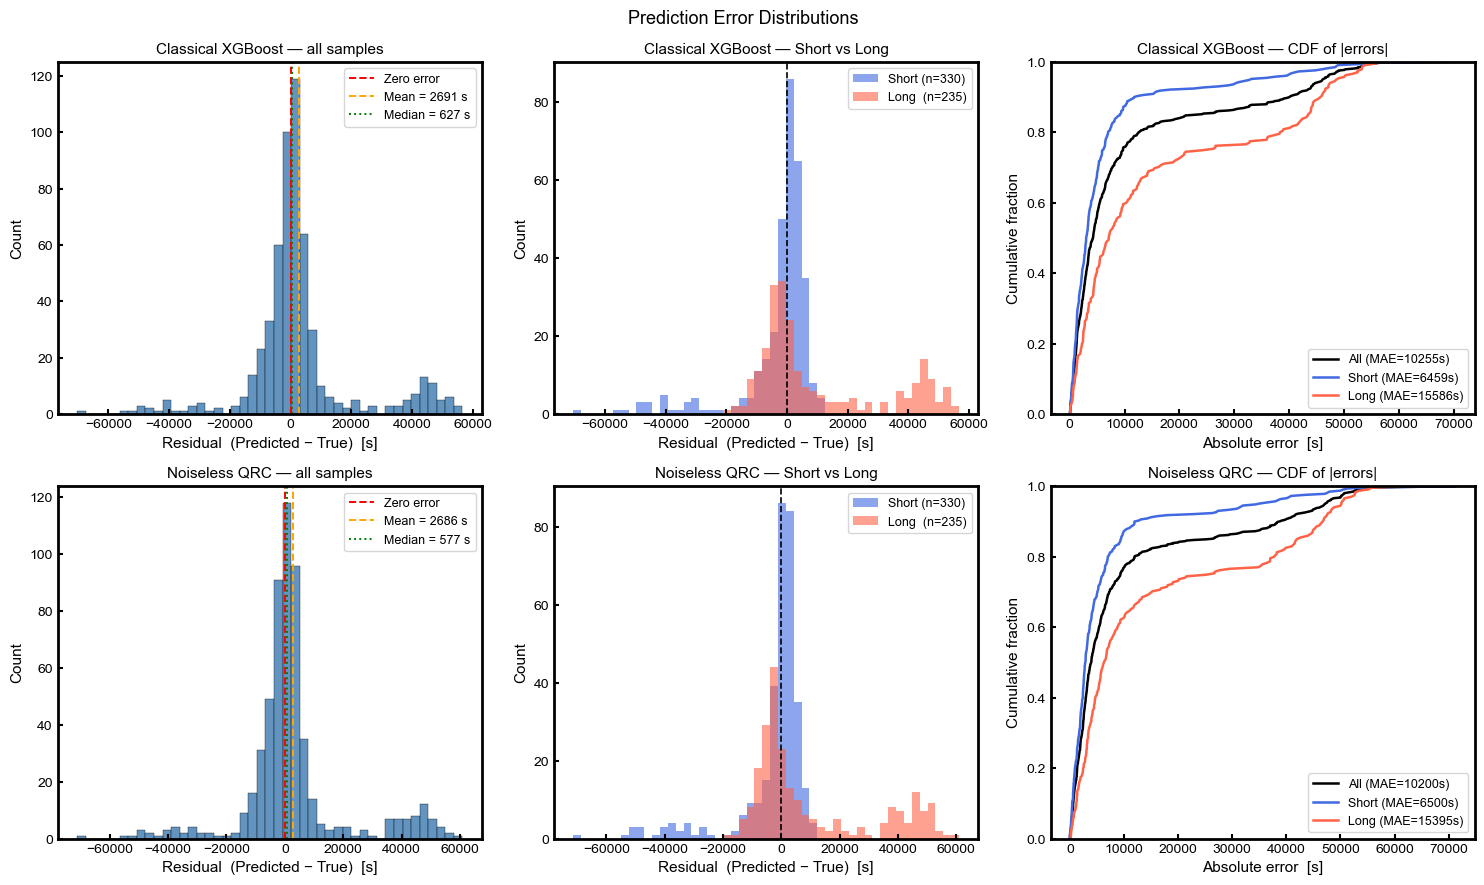

In [ ]:
# ── Error distribution plots — Classical & QRC (if available) ────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

# ── Detect QRC ────────────────────────────────────────────────────────────────
try:
    _qrc_preds_ed = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False
    print("Note: ensemble_pred not found — only classical panels shown.")

short_clf_idx = np.where(clf_test_labels == 0)[0]
long_clf_idx  = np.where(clf_test_labels == 1)[0]

def _plot_error_dist(fig_axes, preds, label_prefix):
    """Draw three error-distribution panels for a given set of predictions."""
    axes = fig_axes
    errors_all  = preds - y_test_np
    abs_err_all = np.abs(errors_all)
    errors_short = errors_all[short_clf_idx]
    errors_long  = errors_all[long_clf_idx]

    # Panel 1: signed residual histogram
    ax = axes[0]
    ax.hist(errors_all, bins=45, color='steelblue', edgecolor='black',
            linewidth=0.3, alpha=0.85)
    ax.axvline(0,                  color='red',    linestyle='--', lw=1.4, label='Zero error')
    ax.axvline(errors_all.mean(),  color='orange', linestyle='--', lw=1.4,
               label=f'Mean = {errors_all.mean():.0f} s')
    ax.axvline(np.median(errors_all), color='green', linestyle=':', lw=1.4,
               label=f'Median = {np.median(errors_all):.0f} s')
    ax.set_xlabel('Residual  (Predicted − True)  [s]', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{label_prefix} — all samples', fontsize=11)
    ax.legend(fontsize=9)

    # Panel 2: regime-split residuals
    ax = axes[1]
    bins = np.linspace(errors_all.min(), errors_all.max(), 50)
    ax.hist(errors_short, bins=bins, alpha=0.6, color='royalblue',
            edgecolor='none', label=f'Short (n={len(errors_short)})')
    ax.hist(errors_long,  bins=bins, alpha=0.6, color='tomato',
            edgecolor='none', label=f'Long  (n={len(errors_long)})')
    ax.axvline(0, color='black', linestyle='--', lw=1.2)
    ax.set_xlabel('Residual  (Predicted − True)  [s]', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{label_prefix} — Short vs Long', fontsize=11)
    ax.legend(fontsize=9)

    # Panel 3: CDF of absolute errors
    ax = axes[2]
    for lbl, idx, colour in [
        ('All',   np.arange(len(y_test_np)), 'black'),
        ('Short', short_clf_idx,             'royalblue'),
        ('Long',  long_clf_idx,              'tomato'),
    ]:
        ae  = np.sort(np.abs(errors_all[idx]))
        cdf = np.arange(1, len(ae) + 1) / len(ae)
        ax.plot(ae, cdf, color=colour, lw=1.8,
                label=f'{lbl} (MAE={mean_absolute_error(y_test_np[idx], preds[idx]):.0f}s)')
    ax.set_xlabel('Absolute error  [s]', fontsize=11)
    ax.set_ylabel('Cumulative fraction', fontsize=11)
    ax.set_title(f'{label_prefix} — CDF of |errors|', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)


n_rows = 2 if _qrc_available else 1
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4.5 * n_rows))
fig.suptitle('Prediction Error Distributions', fontsize=13)

if n_rows == 1:
    axes = axes[np.newaxis, :]   # make 2-D for uniform indexing

_plot_error_dist(axes[0], final_predictions, 'Classical XGBoost')
if _qrc_available:
    _plot_error_dist(axes[1], _qrc_preds_ed, 'Noiseless QRC')

plt.tight_layout()
plt.show()


In [ ]:
# ──  Per-sample regime probabilities (soft classification) ────────────────
import pandas as pd
import numpy as np

# ── Detect QRC ────────────────────────────────────────────────────────────────
try:
    _qrc_preds_ps = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    _qrc_available = False

clf_test_proba_all = slip_classifier.predict_proba(X_test_raw)   # (n, 2)
prob_short = clf_test_proba_all[:, 0]
prob_long  = clf_test_proba_all[:, 1]
hard_label = clf_test_labels

row = {
    'True_TTNS_s'       : y_test_np,
    'Classical_Pred_s'  : final_predictions,
    'Classical_AbsErr_s': np.abs(final_predictions - y_test_np),
}
if _qrc_available:
    row['QRC_Pred_s']       = _qrc_preds_ps
    row['QRC_AbsErr_s']     = np.abs(_qrc_preds_ps - y_test_np)

row.update({
    'P_Short'   : prob_short,
    'P_Long'    : prob_long,
    'Regime'    : ['Short' if l == 0 else 'Long' for l in hard_label],
    'Max_Conf'  : np.maximum(prob_short, prob_long),
})

results_df = pd.DataFrame(row)
results_df_sorted = results_df.sort_values('Max_Conf', ascending=False).reset_index(drop=True)

print("Per-sample results with regime probabilities (sorted by confidence)")
print("=" * 80)
print(results_df_sorted.to_string(index=True, float_format=lambda x: f'{x:,.2f}'))

# Summary stats by regime
err_cols = ['Classical_AbsErr_s'] + (['QRC_AbsErr_s'] if _qrc_available else [])
print("\n" + "=" * 60)
print("Summary statistics by hard regime label:")
print(results_df.groupby('Regime')[err_cols + ['P_Short', 'P_Long', 'Max_Conf']].describe().round(2))


Per-sample results with regime probabilities (sorted by confidence)
     True_TTNS_s  Classical_Pred_s  Classical_AbsErr_s  QRC_Pred_s  QRC_AbsErr_s  P_Short  P_Long Regime  Max_Conf
0      61,725.00         60,700.60            1,024.40   60,895.35        829.65     0.97    0.03  Short      0.97
1      56,250.00         57,207.95              957.95   56,164.42         85.58     0.97    0.03  Short      0.97
2      47,445.00         50,061.65            2,616.65   49,338.39      1,893.39     0.97    0.03  Short      0.97
3      29,355.00         32,548.98            3,193.98   34,424.41      5,069.41     0.97    0.03  Short      0.97
4      43,395.00         45,636.25            2,241.25   45,061.21      1,666.21     0.96    0.04  Short      0.96
5      54,630.00         54,533.40               96.60   54,665.47         35.47     0.96    0.04  Short      0.96
6      56,220.00         60,662.03            4,442.03   56,655.45        435.45     0.96    0.04  Short      0.96
7      37,23

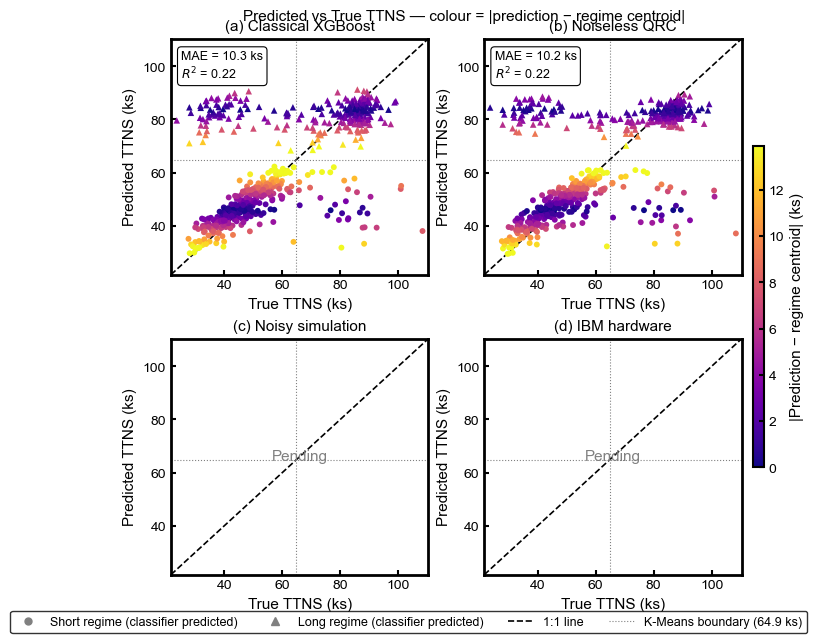

Saved to four_panel_centroid_dist.png


In [ ]:
# ── Four-panel plot — colorbar = distance from K-Means centroid ──────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, r2_score

mpl.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.linewidth':    2,
    'axes.edgecolor':    'black',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.grid':         False,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

# ── Detect QRC ────────────────────────────────────────────────────────────────
try:
    qrc_preds_cd = np.array(ensemble_pred)
    _qrc_available = True
except NameError:
    qrc_preds_cd  = None
    _qrc_available = False
    print("Note: ensemble_pred not found — QRC panel will show 'Pending'.")

# ── Distance of PREDICTION from the classifier-assigned regime centroid ───────
# centroid_dist[i] = |predicted_value[i] - centroid_of_predicted_regime[i]|
# This shows how far each model's output lands from the centre of the regime
# it was routed to — bright points are predictions far from their centroid.
assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
centroid_dist   = np.abs(classical_preds - assigned_center)  # uses predictions, not y_true

y_true          = np.array(y_test_np)
classical_preds = np.array(final_predictions)
classical_centroid_dist = centroid_dist   # already computed above for classical

# QRC centroid dist — distance of QRC predictions from their assigned centroid
if _qrc_available:
    qrc_centroid_dist = np.abs(qrc_preds_cd - assigned_center)
else:
    qrc_centroid_dist = None

short_idx_mask = clf_test_labels == 0
long_idx_mask  = clf_test_labels == 1
km_boundary    = centers.mean()

_ref_preds = [y_true, classical_preds] + ([qrc_preds_cd] if _qrc_available else [])
all_vals   = np.concatenate(_ref_preds)
ax_min     = max(0, np.min(all_vals) - 2000)
ax_max     = np.max(all_vals) + 2000
diag       = [ax_min, ax_max]

vmin_c, vmax_c = 0, np.percentile(classical_centroid_dist, 95)
cmap_c = plt.cm.plasma
norm_c = mpl.colors.Normalize(vmin=vmin_c, vmax=vmax_c)


def scatter_centroid(ax, y_true, y_pred, dist, title,
                     short_mask, long_mask, is_placeholder=False):
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.plot(diag, diag, color='black', linewidth=1.2, linestyle='--', zorder=1)
    ax.axvline(km_boundary, color='grey', linestyle=':', linewidth=0.8, zorder=1)
    ax.axhline(km_boundary, color='grey', linestyle=':', linewidth=0.8, zorder=1)

    if is_placeholder:
        ax.text(0.5, 0.5, 'Pending', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='gray')
        ax.set_title(title, fontsize=11, pad=6)
        ax.set_xlabel('True TTNS (ks)', fontsize=11)
        ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
        _fmt_ks(ax)
        return

    ax.scatter(y_true[short_mask], y_pred[short_mask],
               c=dist[short_mask], cmap=cmap_c, norm=norm_c,
               s=18, marker='o', edgecolors='none', zorder=2)
    ax.scatter(y_true[long_mask],  y_pred[long_mask],
               c=dist[long_mask],  cmap=cmap_c, norm=norm_c,
               s=22, marker='^', edgecolors='none', zorder=2)

    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    ax.text(0.04, 0.95,
            f'MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', linewidth=0.8))
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('True TTNS (ks)', fontsize=11)
    ax.set_ylabel('Predicted TTNS (ks)', fontsize=11)
    _fmt_ks(ax)


def _fmt_ks(ax):
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))


fig, axes = plt.subplots(2, 2, figsize=(6.89, 6.0), constrained_layout=True)

scatter_centroid(axes[0, 0], y_true, classical_preds, classical_centroid_dist,
                 '(a) Classical XGBoost', short_idx_mask, long_idx_mask)
scatter_centroid(axes[0, 1], y_true, qrc_preds_cd,
                 qrc_centroid_dist if _qrc_available else None,
                 '(b) Noiseless QRC', short_idx_mask, long_idx_mask,
                 is_placeholder=not _qrc_available)
scatter_centroid(axes[1, 0], y_true, None, None,
                 '(c) Noisy simulation', short_idx_mask, long_idx_mask,
                 is_placeholder=True)
scatter_centroid(axes[1, 1], y_true, None, None,
                 '(d) IBM hardware', short_idx_mask, long_idx_mask,
                 is_placeholder=True)

sm_c = mpl.cm.ScalarMappable(cmap=cmap_c, norm=norm_c)
sm_c.set_array([])
cbar_c = fig.colorbar(sm_c, ax=axes, shrink=0.6, pad=0.02, aspect=30)
cbar_c.set_label('|Prediction − regime centroid| (ks)', fontsize=11)
cbar_c.ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}'))
cbar_c.ax.tick_params(labelsize=10)
cbar_c.outline.set_linewidth(1.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='gray', linestyle='None',
           markersize=5, label='Short regime (classifier predicted)'),
    Line2D([0], [0], marker='^', color='gray', linestyle='None',
           markersize=6, label='Long regime (classifier predicted)'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='1:1 line'),
    Line2D([0], [0], color='grey', linestyle=':',
           linewidth=0.8, label=f'K-Means boundary ({km_boundary/1000:.1f} ks)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           frameon=True, edgecolor='black', bbox_to_anchor=(0.42, -0.04))

plt.suptitle('Predicted vs True TTNS — colour = |prediction − regime centroid|',
             fontsize=11, y=1.01)

output_path = 'four_panel_centroid_dist.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to {output_path}")
